<img src="MUML_header.svg" alt="Header" style="width:100%; height:auto;">

# 01_02 Naive Bayes

In this notebook you will:

- Revisit scikit-learn.
- Learn Naive Bayes:
  - GaussianNB for continuous features.
  - MultinomialNB for discrete counts.
- Use `predict_proba` to inspect class probabilities.
- Plot histograms per class for intuition.
- Introduce `train_test_split` to compare training vs test performance.
- Convert raw text to features with `CountVectorizer`.

## Gaussian Naive Bayes on Wine dataset

### Step 1: Load the Wine dataset and keep NumPy arrays

- Use [`load_wine()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) to load the Wine dataset.
- Prepare:
  - `X` as a NumPy array of shape `(n_samples, n_features)`.
  - `y` as integer class ids (0,1,2).
  - `y_names` as string class names (you can use `wine.target_names`).


In [23]:
import pandas as pd
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
df = wine.frame
#print(df.info())
#print(df.head())

X = df.iloc[:,:-1]
#print(X.head())
y = df['target']
#print(y.head)
y_names = wine.target_names
#print(y_names)



### Step 2: Train a Gaussian Naive Bayes model

- Create an instance of `GaussianNB()`.
- Train the model with the data
- Print the predicted classes for the data
- Print the learned class labels via `.classes_`.
- Compute the percentage of correctly classified instances on the same data


In [24]:
from sklearn.naive_bayes import GaussianNB
#- Create an instance of `GaussianNB()`.
gNB = GaussianNB()
#- Train the model with the data
gNB.fit(X, y)
#- Print the predicted classes for the data
predictions = gNB.predict(X)
print(predictions)
#- Print the learned class labels via `.classes_`.
print(gNB.classes_)
#- Compute the percentage of correctly classified instances on the same data
accuracy = gNB.score(X, y)
print(f"Accuracy: {accuracy:.2%}")



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[0 1 2]
Accuracy: 98.88%


### Step 3: Use `predict_proba` to see class probabilities
 So far, we used `.predict(X)` which gives the **most likely class** for each instance.  
- With `.predict_proba(X)` we can inspect the **full probability distribution over all classes**.  
  - Each row corresponds to one sample.  
  - Each column corresponds to one class.  
  - Values are probabilities and **sum to 1 across a row**.  
- This is useful when we want to know not only the predicted class, but also **how confident** the model is.  

**What to do:**
1. Call `.predict_proba(X)` and print the first few rows.  
2. Verify that row sums are equal to 1.  
3. Compare it with `.predict(X)` by checking that the predicted label corresponds to the class with the **highest probability** in the row.  



In [25]:
#1. Call `.predict_proba(X)` and print the first few rows.  
probabilities = gNB.predict_proba(X)
print(probabilities[:5])

#2. Verify that row sums are equal to 1. 
row_sums = probabilities.sum(axis=1)
print(row_sums[:5])  
#3. Compare it with `.predict(X)` by checking that the predicted label corresponds to the class with the **highest probability** in the row.
class_with_highest_prob = probabilities.argmax(axis=1)
print(class_with_highest_prob[:5])
predicted_labels = gNB.predict(X)
print(predicted_labels[:5])

(class_with_highest_prob == predicted_labels)[:5]


[[1.00000000e+00 1.37601891e-10 7.68922286e-41]
 [9.99981527e-01 1.84733443e-05 3.76592736e-30]
 [9.99999995e-01 5.30731930e-09 1.94292226e-35]
 [1.00000000e+00 8.33765645e-19 1.29175953e-49]
 [9.65501133e-01 3.44988665e-02 5.36335903e-19]]
[1. 1. 1. 1. 1.]
[0 0 0 0 0]
[0 0 0 0 0]


array([ True,  True,  True,  True,  True])

### Step 4: Inspect the parameters learned by GaussianNB

When we train a Gaussian Naive Bayes model, it estimates simple statistical parameters for each class and feature:  

- **`.class_prior_`** → the prior probability of each class, estimated from the relative frequencies of the training data (unless specified manually).  
- **`.theta_`** → the mean of each feature within each class. Each row corresponds to a class, and each column to a feature.  
- **`.var_`** → the variance of each feature within each class. Together with the means, this defines the Gaussian distribution used for that feature in that class.  

These parameters allow GaussianNB to compute the probability of a sample belonging to a class by multiplying the Gaussian likelihoods of its features (assuming independence).  

**Note:** if a feature is actually discrete (e.g., categorical encoded as integers), GaussianNB will still treat it as if it came from a continuous Gaussian distribution. In practice this may be a poor fit, but the model still produces means and variances. If the data is truly categorical, a different variant such as `CategoricalNB` or `MultinomialNB` should be used.  

**What to do:**
1. Print `.class_prior_`.  
2. Wrap `.theta_` into a DataFrame for readability (rows = classes, columns = features).  
3. Do the same with `.var_`.  
4. Inspect these tables to see the per-class means and variances.  



In [26]:
#1. Print `.class_prior_`.  
print(gNB.class_prior_)
#2. Wrap `.theta_` into a DataFrame for readability (rows = classes, columns = features).  
theta_df = pd.DataFrame(gNB.theta_, index=gNB.classes_, columns=gNB.feature_names_in_)
#3. Do the same with `.var_`.  
var_df = pd.DataFrame(gNB.var_, index=gNB.classes_, columns=gNB.feature_names_in_)
#4. Inspect these tables to see the per-class means and variances.  
print("Per-class means:")
print(theta_df)
print("\nPer-class variances:")
print(var_df)

[0.33146067 0.3988764  0.26966292]
Per-class means:
     alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
0  13.744746    2.010678  2.455593          17.037288  106.338983   
1  12.278732    1.932676  2.244789          20.238028   94.549296   
2  13.153750    3.333750  2.437083          21.416667   99.312500   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       2.840169    2.982373              0.290000         1.899322   
1       2.258873    2.080845              0.363662         1.630282   
2       1.678750    0.781458              0.447500         1.153542   

   color_intensity       hue  od280/od315_of_diluted_wines      proline  
0         5.528305  1.062034                      3.157797  1115.711864  
1         3.086620  1.056282                      2.785352   519.507042  
2         7.396250  0.682708                      1.683542   629.895833  

Per-class variances:
    alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \


### Step 5: Evaluate generalization with a train/test split

So far, we have measured the model’s performance on the same data it was trained on.  
This training accuracy is usually over-optimistic because the model has already seen those examples.  
To get a more honest estimate of how the model generalizes to unseen data, we split our dataset into two parts:  

- **Training set** → used to fit the model parameters.  
- **Test set** → held out and used only to evaluate performance after training.  

In scikit-learn, this is done with the function `train_test_split`. Important arguments are:  

- `test_size` → fraction of data to put in the test set (e.g. `0.3` for 30%).  
- `random_state` → a seed to make the split reproducible.  
- `stratify=y` → ensures that class proportions are similar in both train and test sets (very important for classification).  

**What to do:**  
1. Import `train_test_split` from `sklearn.model_selection`.  
2. Split `X` and `y` into `X_train, X_test, y_train, y_test` using a 70/30 split, with `random_state=42` and `stratify=y`.  
3. Fit a new `GaussianNB` model on the training set.  
4. Print training accuracy and test accuracy with `.score()`.  


In [27]:
#1. Import `train_test_split` from `sklearn.model_selection`.
from sklearn.model_selection import train_test_split  
#2. Split `X` and `y` into `X_train, X_test, y_train, y_test` using a 70/30 split, with `random_state=42` and `stratify=y`.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#3. Fit a new `GaussianNB` model on the training set.
new_gNB = GaussianNB()
new_gNB.fit(X_train, y_train)
#4. Print training accuracy and test accuracy with `.score()`.
print("Training accuracy:", new_gNB.score(X_train, y_train))
print("Test accuracy:", new_gNB.score(X_test, y_test))


Training accuracy: 0.967741935483871
Test accuracy: 1.0


### Step 6: Plot histograms of selected features by class

Now we want to look at the distribution of specific features (e.g., `"alcohol"` or `"color_intensity"`) for each class.  
This lets us see how separable the classes are based on individual features, and also check how well the Gaussian assumption might fit.  

- Plot two histograms, one for each of the feature values (`"alcohol"` or `"color_intensity"`) for each class on the same axes, using transparency so the distributions can be compared.


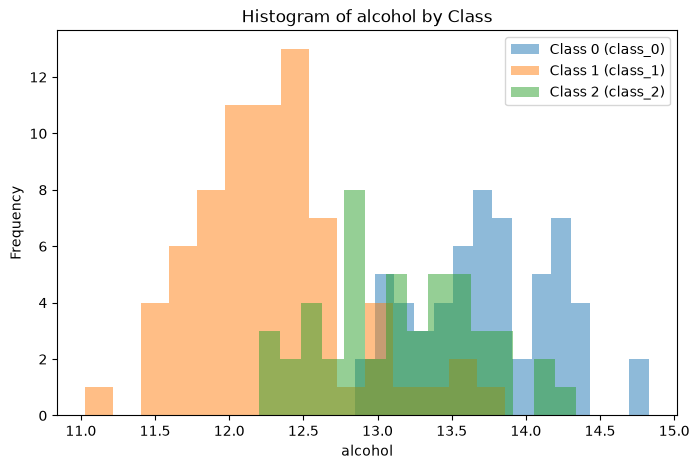

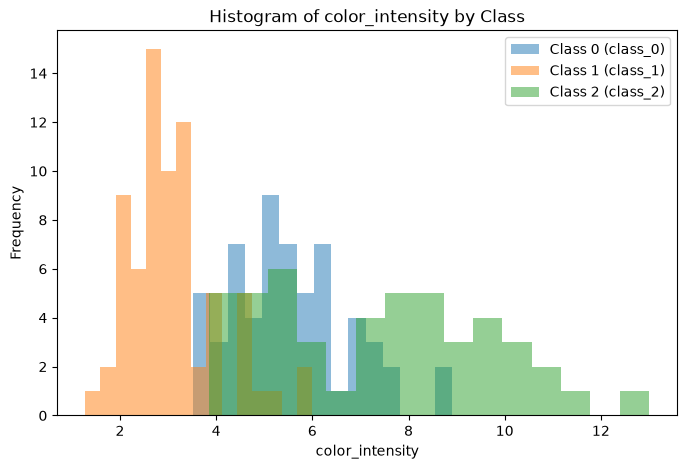

In [28]:
#- Plot two histograms, one for each of the feature values (`"alcohol"` or `"color_intensity"`)
#  for each class on the same axes, using transparency so the distributions can be compared.
import matplotlib.pyplot as plt
features_to_plot = ["alcohol", "color_intensity"]
for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    for class_label in gNB.classes_:
        mask = (y == class_label)
        subset = df[mask]
        plt.hist(subset[feature], alpha=0.5, label=f'Class {class_label} ({y_names[class_label]})', bins=15)
    plt.title(f'Histogram of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


## MultinomialNB for text

Now we move to **text data**, which requires a different representation:  

- Raw text (documents, articles, emails, …) cannot be used directly by machine learning models.  
- A simple and very common approach is the **bag-of-words** model:  
  - We build a vocabulary of all words that appear in the corpus.  
  - Each document is then represented as a vector of **word counts** (how many times each word appears).  
  - This is done automatically with scikit-learn’s `CountVectorizer`.  

The result is a large but sparse matrix, where:  
- Rows = documents  
- Columns = words in the vocabulary  
- Entries = counts of that word in that document

For this kind of data, Naive Bayes with a Multinomial distribution (`MultinomialNB`) is a natural choice because it models features as discrete counts.  

### Step 1: Load a text dataset and build a bag-of-words representation

We will use a subset of the **20 Newsgroups dataset**, a collection of Usenet newsgroup posts on different topics.  
It is a standard benchmark for text classification in scikit-learn.  
To keep things simple, we’ll select only **two categories** (e.g. `"rec.sport.hockey"` and `"sci.space"`).  

**What to do:**  
1. Import `fetch_20newsgroups` from `sklearn.datasets`.

 ~~~
    news_train = fetch_20newsgroups(
    subset="train",
    categories=["rec.sport.hockey", "sci.space"],
    remove=("headers", "footers", "quotes"))

3. Load the training subset with two chosen categories.  
4. Store the raw text documents in `docs` and their labels in `y_text`.  
5. Inspect the class names via `target_names`.  

In [29]:
from sklearn.datasets import fetch_20newsgroups

#3. Load the training subset with two chosen categories.
news_train = fetch_20newsgroups(
    subset="train",
    categories=["rec.sport.hockey", "sci.space"],
    remove=("headers", "footers", "quotes"))


#4. Store the raw text documents in `docs` and their labels in `y_text`. 
docs = news_train.data
y_text = news_train.target

#5. Inspect the class names via `target_names`.
print(news_train.target_names)




['rec.sport.hockey', 'sci.space']


### Step 2: Convert text documents into a bag-of-words matrix

Now that we have raw text documents, we need to transform them into numerical features.  
We will use **`CountVectorizer`**, which implements the **bag-of-words** model:

- It builds a **vocabulary** of all words in the dataset (after preprocessing).  
- Each document is converted into a vector of **word counts**.  
- The result is a **document–term matrix** with shape `(n_documents, n_words)`.  

**Note:** By default, this matrix is stored as a **sparse matrix** (`scipy.sparse.csr_matrix`),  
because most words do not appear in most documents. This is normal and efficient.  

**What to do:**  
1. Import `CountVectorizer` from `sklearn.feature_extraction.text`.  
2. Create a vectorizer with reasonable settings, for example:  
   - `stop_words="english"` → ignore common English words like “the”, “and”.  
   - `max_features=4000` → keep at most 4000 words in the vocabulary.  
   - `min_df=2` → ignore words that appear in only 1 document.  
3. Call `.fit_transform(docs)` to build the vocabulary and transform documents into a sparse count matrix `X_text`.  
4. Print the shape of `X_text` (documents × vocabulary size).  
5. Print the first 10 feature names from the vocabulary.  
6. Optionally: convert a small slice of `X_text` to dense with `.toarray()` just to see the counts.  


In [30]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words="english", max_features=4000, min_df=2)
X_text = cv.fit_transform(docs)
print(X_text.shape)
print("First 10 features:\n", cv.get_feature_names_out()[:10])

converted_small = X_text[:5].toarray()
print("Converted small array:\n", converted_small)  


(1193, 4000)
First 10 features:
 ['00' '000' '005' '01' '02' '03' '04' '05' '06' '0666']
Converted small array:
 [[45  0  0 ...  0  0  1]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


### Step 3: Train a Multinomial Naïve Bayes model and inspect probabilities

Now that `X_text` is a **sparse bag-of-words matrix** and `y_text` are the labels, we can train a text classifier.

- Create an instance of `MultinomialNB`.
- Train the model on `(X_text, y_text)` (it accepts scipy sparse matrices directly).  

- Use `.predict_proba` to see the class probability distribution for a few documents.
- Compute the training accuracy.


In [31]:
from sklearn.naive_bayes import MultinomialNB
#- Create an instance of `MultinomialNB()`.
nb = MultinomialNB()
nb.fit(X_text, y_text)
nb_predictions = nb.predict(X_text)
print(nb_predictions[:10])
print("Probabilities for the first 10 documents:\n", nb.predict_proba(X_text)[:10])

train_accuracy = nb.score(X_text, y_text)
print(f"Training accuracy: {train_accuracy:.2%}")

[0 0 1 0 1 0 0 1 1 0]
Probabilities for the first 10 documents:
 [[1.00000000e+000 0.00000000e+000]
 [1.00000000e+000 3.13814140e-020]
 [3.00401772e-038 1.00000000e+000]
 [7.76292958e-001 2.23707042e-001]
 [1.57950141e-022 1.00000000e+000]
 [1.00000000e+000 2.85081540e-011]
 [9.99999222e-001 7.78372872e-007]
 [5.71397513e-025 1.00000000e+000]
 [6.06551013e-196 1.00000000e+000]
 [1.00000000e+000 3.11715486e-013]]
Training accuracy: 96.56%


### Step 4: Train/test split for text — check generalization


* Split the bag-of-words matrix `X_text` and labels `y_text` into train/test:
   - `test_size=0.3`, `random_state=42`, `stratify=y_text`.
* Fit a fresh `MultinomialNB` on the training split.
* Report training and test accuracies.



In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.3, random_state=42, stratify=y_text)
fresh_nb = MultinomialNB()
fresh_nb.fit(X_train, y_train)
train_accuracy = fresh_nb.score(X_train, y_train)
print(f"Training accuracy: {train_accuracy:.2%}")
test_accuracy = fresh_nb.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2%}")

Training accuracy: 96.29%
Test accuracy: 94.69%


### Step 5: Building a Pipeline for text classification

So far we separated the steps: first used `CountVectorizer` to transform the text,  
then trained `MultinomialNB` on the resulting bag-of-words matrix.  

In practice, it is convenient to chain these steps together into a Pipeline:  
- The raw text is passed directly into the pipeline.  
- The pipeline should first run `CountVectorizer`.  
- Then it should apply `MultinomialNB`.  
- The result behaves just like any other scikit-learn estimator with `.fit`, `.predict`, and `.score`.  

**What to do:**  
1. Import `Pipeline` from `sklearn.pipeline`.  
2. Build a pipeline with two steps:  
   - `"vect"` → `CountVectorizer(stop_words="english", max_features=4000, min_df=2)`  
   - `"clf"`  → `MultinomialNB(alpha=1.0)`   
3. Fit the pipeline on the training data.  
4. Print training and test accuracy.  
5. Try changing the vectorizer settings (e.g. `ngram_range`, `binary=True`, `min_df`) and see how performance changes.  


In [43]:
X_train, X_test, y_train, y_test = train_test_split(docs, y_text, test_size=0.3, random_state=42, stratify=y_text)


pipeline = Pipeline([
    ("vect", CountVectorizer(
        stop_words="english",
        max_features=4000,
        min_df=2
    )),
    ("clf", MultinomialNB(alpha=1.0))
])

# Train
pipeline.fit(X_train, y_train)

# Accuracy
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

param_grid = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [1, 2, 3],
    "vect__binary": [False, True],
    "clf__alpha": [0.1, 0.5, 1.0]
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print("Test accuracy:", grid_search.score(X_test, y_test))


 


Training accuracy: 0.9665
Test accuracy: 0.9469
Best parameters: {'clf__alpha': 0.1, 'vect__binary': False, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}
Best CV accuracy: 0.9544910179640718
Test accuracy: 0.9441340782122905
